# Aer Noise Models

## Overview
Ideal quantum circuits assume perfectly unitary gates and perfect measurement. Real devices violate both assumptions. Qiskit Aer lets us encode these non-ideal effects through **noise models**, which can include gate errors, relaxation effects, and readout errors.

Formally, noisy evolution is modeled with quantum channels $(\mathcal{E})$, not only unitary operators. A common example is depolarization:
$
\mathcal{E}(ho)=(1-p)ho + p\,\frac{I}{2^n},
$
where $(p)$ controls noise strength and $(n)$ is the number of qubits affected.

In this experiment you will:
- Build reference circuits with known ideal distributions.
- Construct a composite Aer noise model.
- Compare ideal and noisy output distributions quantitatively.

**Prerequisites:** Density matrices/channels at a conceptual level, basic two-qubit circuits.

**Qiskit version pin:** `qiskit==2.3.0` (Aer simulators via `qiskit_aer`).

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import qiskit
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, ReadoutError, depolarizing_error, amplitude_damping_error

print(f"Qiskit version: {qiskit.__version__}")
print("Aer noise modules imported successfully.")

Qiskit version: 2.3.0
Aer noise modules imported successfully.


## Build reference circuits and inspect them

In [2]:
single_qubit_circuit = QuantumCircuit(1, 1)
single_qubit_circuit.h(0)
single_qubit_circuit.measure(0, 0)

bell_measurement_circuit = QuantumCircuit(2, 2)
bell_measurement_circuit.h(0)
bell_measurement_circuit.cx(0, 1)
bell_measurement_circuit.barrier(label='Measure Bell basis outcomes')
bell_measurement_circuit.measure([0, 1], [0, 1])

print("Single-qubit reference circuit:")
print(single_qubit_circuit.draw(output='text'))
print("\nBell-state measurement circuit:")
print(bell_measurement_circuit.draw(output='text'))

Single-qubit reference circuit:
     ┌───┐┌─┐
  q: ┤ H ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 

Bell-state measurement circuit:
     ┌───┐      Measure Bell basis outcomes ┌─┐   
q_0: ┤ H ├──■────────────────░──────────────┤M├───
     └───┘┌─┴─┐              ░              └╥┘┌─┐
q_1: ─────┤ X ├──────────────░───────────────╫─┤M├
          └───┘              ░               ║ └╥┘
c: 2/════════════════════════════════════════╩══╩═
                                             0  1 


## Construct a composite Aer noise model
We include:
- Single-qubit depolarizing gate noise.
- Two-qubit depolarizing noise on `cx`.
- Amplitude damping on single-qubit gates.
- Readout error on each qubit.

This gives a realistic mixed-noise scenario without invoking any remote hardware.

In [6]:
noise_model = NoiseModel()

single_qubit_depolarizing = depolarizing_error(param = 0.1, num_qubits = 1)
two_qubit_depolarizing = depolarizing_error(param = 0.3, num_qubits = 2)
amplitude_damping = amplitude_damping_error(param_amp = 0.2)

noise_model.add_all_qubit_quantum_error(single_qubit_depolarizing, ['h', 'x', 'sx'])
noise_model.add_all_qubit_quantum_error(amplitude_damping, ['h', 'x', 'sx'])
noise_model.add_all_qubit_quantum_error(two_qubit_depolarizing, ['cx'])

readout_matrix = [[0.97, 0.03], [0.04, 0.96]]
readout_error = ReadoutError(readout_matrix)
noise_model.add_all_qubit_readout_error(readout_error)

print(noise_model)

NoiseModel:
  Basis gates: ['cx', 'h', 'id', 'rz', 'sx', 'x']
  Instructions with noise: ['sx', 'cx', 'x', 'measure', 'h']
  All-qubits errors: ['h', 'x', 'sx', 'cx', 'measure']


## Run ideal vs noisy simulations

In [8]:
def run_counts(circuit: QuantumCircuit, shots: int, noisy: bool) -> dict:
    """Run circuit on Aer with or without noise and return counts."""
    backend = AerSimulator(noise_model=noise_model) if noisy else AerSimulator()
    transpiled = transpile(circuit, backend)
    result = backend.run(transpiled, shots=shots).result()
    return result.get_counts(transpiled)

shots = 10000
ideal_single_counts = run_counts(single_qubit_circuit, shots=shots, noisy=False)
noisy_single_counts = run_counts(single_qubit_circuit, shots=shots, noisy=True)

ideal_bell_counts = run_counts(bell_measurement_circuit, shots=shots, noisy=False)
noisy_bell_counts = run_counts(bell_measurement_circuit, shots=shots, noisy=True)

print("Single-qubit ideal counts:", ideal_single_counts)
print("Single-qubit noisy counts:", noisy_single_counts)
print("\nBell ideal counts:", ideal_bell_counts)
print("Bell noisy counts:", noisy_bell_counts)

Single-qubit ideal counts: {'0': 5008, '1': 4992}
Single-qubit noisy counts: {'0': 5896, '1': 4104}

Bell ideal counts: {'00': 4965, '11': 5035}
Bell noisy counts: {'01': 931, '11': 3295, '10': 1019, '00': 4755}


## Visual comparison of distributions

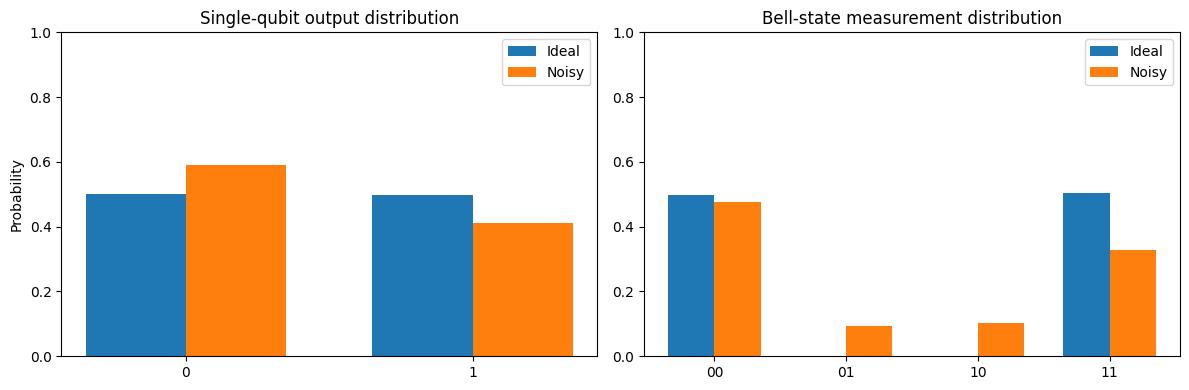

In [9]:
def normalized_distribution(counts: dict, ordered_bitstrings: list, shots: int) -> list:
    """Convert counts to a probability list in a fixed bitstring order."""
    return [counts.get(bitstring, 0) / shots for bitstring in ordered_bitstrings]

single_labels = ['0', '1']
bell_labels = ['00', '01', '10', '11']

ideal_single_probs = normalized_distribution(ideal_single_counts, single_labels, shots)
noisy_single_probs = normalized_distribution(noisy_single_counts, single_labels, shots)
ideal_bell_probs = normalized_distribution(ideal_bell_counts, bell_labels, shots)
noisy_bell_probs = normalized_distribution(noisy_bell_counts, bell_labels, shots)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bar_width = 0.35

x_single = np.arange(len(single_labels))
axes[0].bar(x_single - bar_width / 2, ideal_single_probs, width=bar_width, label='Ideal')
axes[0].bar(x_single + bar_width / 2, noisy_single_probs, width=bar_width, label='Noisy')
axes[0].set_xticks(x_single)
axes[0].set_xticklabels(single_labels)
axes[0].set_ylim(0, 1)
axes[0].set_title('Single-qubit output distribution')
axes[0].set_ylabel('Probability')
axes[0].legend()

x_bell = np.arange(len(bell_labels))
axes[1].bar(x_bell - bar_width / 2, ideal_bell_probs, width=bar_width, label='Ideal')
axes[1].bar(x_bell + bar_width / 2, noisy_bell_probs, width=bar_width, label='Noisy')
axes[1].set_xticks(x_bell)
axes[1].set_xticklabels(bell_labels)
axes[1].set_ylim(0, 1)
axes[1].set_title('Bell-state measurement distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

## Summary
| Component | Role in model | Typical effect |
|---|---|---|
| Depolarizing error | Random Pauli-like mixing | Flattens ideal distributions |
| Amplitude damping | Energy relaxation toward $|0\rangle$ | Bias toward `0` outcomes |
| Readout error | Classical assignment flips | Distorts measured counts |

**Key takeaways:**
- Aer noise models combine multiple physical error mechanisms in one simulator.
- Noisy channels convert ideal-state outputs into shifted measurement distributions.
- Noise-aware simulation is essential before interpreting algorithm performance.